<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/16_ml_intro/16_1_Intro_to_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Machine Learning

---

## Learning Objectives

After working through this notebook, you should be able to:

- Explain how machine learning differs from traditional programming and statistics
- Identify whether a problem calls for supervised, unsupervised, or reinforcement learning
- Describe the role of features, labels, training data, and prediction in supervised learning
- Distinguish between classification and regression problems
- Train and evaluate a simple classifier using scikit-learn
- Use an unsupervised clustering algorithm to discover patterns in unlabeled data

---


Machine learning is a sub-field of classical artificial intelligence, wherein algorithms and data are used to build predictive models.
Unlike traditional software engineering, which relies on explicit, hard-coded instructions to perform tasks, machine learning enables systems to learn and adapt autonomously. In traditional Computer Science you are typically working to build fully deterministic programs that reliably produce the same result over and over again. In contrast, machine learning involves learning from data itself, producing models that can make predictions about unseen data, and quantifying our confidence in those predictions. If Computer Science mostly deals in certainty, machine learning, and Data Science as a whole, mostly deals in uncertainty.

Machine learning has a great deal of overlap with statistics, in particular, statistical learning. And we will certainly talk quite a lot about statistics this semester, but the emphasis of the course is different from your typical statistics class. Statistical learning uses tools to understand the underlying relationships between variables and make inferences about the data-generating process. The goal is often to explain why a phenomenon occurs. So you work on creating highly interpretable models that can provide confidence intervals, test hypotheses, and isolate the effect of specific variables. In contrast, machine learning tends to prioritize predictive accuracy and computational efficiency. It is generally more concerned with predicting what the outcome will be. It relies heavily on optimization algorithms and is often willing to trade interpretability for sheer performance, embracing complex, "black-box" models like deep neural networks to tackle large-scale, real-world tasks. Throughout this course we will rely on statistical foundations to ground our understanding; our ultimate focus will be on the engineering side: building, training, and evaluating algorithms that can generalize well and make robust predictions on new, unseen data.

## Some Examples of Machine Learning Problems

Let us consider a few real-world problems that fall into the realm of machine learning rather than traditional computer science or traditional statistics. Take, for instance, the task of filtering spam emails. If we were to approach this using traditional computer science, a programmer would have to manually write hundreds of explicit, rigid rules, such as flagging messages that contain specific words, irregular capitalization, or suspicious sender addresses. However, language is infinitely variable and spammers constantly adapt, making a hard-coded system incredibly brittle and exhausting to maintain. A traditional statistical approach, on the other hand, might focus on formal hypothesis testing to prove exactly *which* words are statistically significant indicators of spam. Machine learning cuts through both: it simply ingests thousands of labeled emails and automatically trains a model to recognize the fluid, complex patterns that distinguish spam from a legitimate message, prioritizing high accuracy and the ability to adapt to new data over explaining the linguistic theory behind the spam.

Consider another classic challenge: computer vision, such as teaching a computer to recognize a handwritten digit or identify a stop sign in a digital image. In traditional programming, it is virtually impossible to write a set of mathematical rules to define a stop sign pixel-by-pixel, because the rules would break the moment the lighting changes, the sign is partially obscured, or the angle shifts. Traditional statistics struggles here as well, because an image contains millions of variables (pixels) interacting in highly non-linear ways, making inference nearly impossible. Machine learning solves this by exposing an algorithm, like a neural network, to vast quantities of images, allowing it to autonomously extract features like edges, shapes, and colors to make a robust prediction.

Finally, think of personalized recommendation systems used by streaming services or online retailers. The goal isn't necessarily to understand the deep psychological reasons why a user likes a particular sci-fi movie (inference), nor is it to hard-code a rule that says "if user likes movie A, recommend movie B" (traditional programming). Instead, the goal is to navigate massive matrices of user behaviors and product features to instantly predict what the user is most likely to click on next. In all of these cases, the sheer scale of the data, the complexity of the rules required, and the focus on predictive performance push us out of the realms of traditional software engineering and statistics, and squarely into the domain of machine learning.

## The Central Role of Data in Machine Learning

Unlike most forms of classical artificial intelligence, machine learning does not rely on human experts to distill their understanding of the world into explicit logic, symbolic representations, or rigid rule-based expert systems. Instead, it is fundamentally empirical, relying entirely on the ingestion of examples to build its intelligence. In this paradigm, data is the indispensable raw material, the lifeblood of the entire process.

Without data, even the most mathematically advanced machine learning algorithm is effectively an empty vessel. The algorithm acts as a highly adaptable framework, absorbing the hidden structures, relationships, and nuances embedded within the dataset. If you want a model to predict housing prices, you don't write a theoretical equation about how adding a bedroom affects the value; you feed the system thousands of historical real estate transactions and let it deduce that relationship on its own.

Consequently, the success or failure of a machine learning system is often dictated less by the sophistication of the algorithm and more by the quantity, quality, and diversity of the data it is trained on. This central dependency introduces its own unique set of challenges. Practitioners must constantly grapple with the foundational principle of "garbage in, garbage out." If the training data is noisy, biased, incomplete, or unrepresentative of the real world, the resulting model will inevitably inherit and amplify those flaws, regardless of how well the algorithm is coded. We will spend a large portion of the semester not trying to get our code to run, but trying to figure out whether the data our code produced is reliable and meaningful. The difference between success and failure is more nuanced here than in most CS courses: code that executes without errors can still produce completely wrong results.

Because data plays such an important role, a significant portion of our time in this course will be spent not just on building or tweaking algorithms, but on gathering, cleaning, exploring, and preparing the data that makes learning possible in the first place.

## Different Kinds of Machine Learning

Machine Learning algorithms can broadly be classified into three primary categories based on the nature of the data they consume and the type of feedback they receive during the training process:

**1. Supervised Learning**
In this category, the algorithm is trained on a "labeled" dataset. This means that every input example provided to the model comes paired with the correct answer, or "ground truth." The model's objective is to learn the underlying mapping from inputs to outputs so that it can accurately predict the labels for entirely new, unseen data.

**2. Unsupervised Learning**
Unlike supervised learning, an unsupervised algorithm is given a dataset with no labels, no categories, and no "correct" answers. The system is entirely on its own, tasked with exploring the data to discover hidden patterns, underlying structures, or relationships that we might not even know exist.

**3. Reinforcement Learning**
This branch of machine learning takes a fundamentally different approach, drawing inspiration from behavioral psychology. Instead of passively analyzing a static dataset, a reinforcement learning algorithm acts as an "agent" that interacts with a dynamic environment. As the agent takes actions, it receives feedback in the form of rewards for beneficial moves and penalties for mistakes. Through continuous trial and error, the agent learns a strategy or "policy" that maximizes its cumulative reward over time.

While these three pillars form the traditional taxonomy, the boundaries frequently blur through hybrid approaches like *semi-supervised learning* and *self-supervised learning*. Our journey will begin with supervised learning, but first, let's see the practical difference between supervised and unsupervised learning by writing actual code.

### How to Use This Notebook

What you are reading right now is a **Jupyter notebook** (also called a Colab notebook). It mixes text cells (like this one) with code cells that you can run. This is the standard format for data science work.

To run a code cell, click the ► button that appears when you hover over it, or press **Ctrl+Enter** while the cell is selected. **Shift+Enter** runs the cell and moves to the next one. Try it on the next cell.

You can also add new code cells using the **+Code** button in the toolbar above.

In [1]:
print("Machine learning starts here!")
print("Hello from my first notebook cell.")

Machine learning starts here!
Hello from my first notebook cell.


### Execution Order
Notice the number that appears in the `[ ]` brackets after you run the cell above. That number tracks the order cells are executed. Code run in one cell can affect code in another cell. Work through this notebook from top to bottom, running each code cell in sequence.

### If You Get Errors
- You may have skipped a cell or run things out of order — go back to the top and choose **Runtime → Run all**.
- If the notebook seems broken, restart the runtime (**Runtime → Restart runtime**) and then run everything again. This won't erase your work.

Now let's set up the tools we need and start coding. Run both of the cells below.

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

In [8]:
np.random.seed(42)
n_per_class = 20

# Danceable songs: higher tempo, higher energy
danceable_tempo = np.random.normal(135, 25, n_per_class)
danceable_energy = np.random.normal(0.8, 0.08, n_per_class)

# Not danceable songs: lower tempo, lower energy
not_danceable_tempo = np.random.normal(95, 15, n_per_class)
not_danceable_energy = np.random.normal(0.3, 0.1, n_per_class)

tempo = np.concatenate([danceable_tempo, not_danceable_tempo])
energy = np.concatenate([danceable_energy, not_danceable_energy])
labels = np.array(['danceable'] * n_per_class + ['not danceable'] * n_per_class)

songs = pd.DataFrame({'tempo': tempo, 'energy': energy, 'label': labels})
songs.head(10)

,tempo,energy,label
0,147.417854,0.917252,danceable
1,131.543392,0.781938,danceable
2,151.192213,0.805402,danceable
3,173.075746,0.686020,danceable
4,129.146166,0.756449,danceable
5,129.146576,0.808874,danceable
6,174.480320,0.707921,danceable
7,154.185868,0.830056,danceable
8,123.263140,0.751949,danceable
9,148.564001,0.776665,danceable


## Introduction to Supervised Learning

Let's return to our DJ problem. I want to know whether a song is danceable based on its tempo and energy.

In traditional programming, we would write explicit rules (e.g., `IF tempo > 120 AND energy > 0.6 THEN danceable = True`). In supervised machine learning, we flip the script. We provide the computer with historical data and the correct answers (labels), and we ask the computer to learn the rules itself.

Let's formalize this:
- **Features (Input Variables):** The clues we give the computer, represented as a vector $x$. For our DJ bot: **Tempo** (BPM) and **Energy**.
- **Target Variable (Class Label):** The output we want to predict, $y$. Here, $y$ is a category: 'danceable' vs. 'not danceable'.
- **Training Data:** Historical examples where we already know both $x$ and $y$. Each song is a pair $(x_i, y_i)$.

The algorithm learns a mapping function $f$ such that $f(x)$ approximates the true label $y$. Once trained, we can predict $\hat{y}$ ("y-hat") for a brand new song.

Because our target is a discrete category, this is a **Classification** problem. If we were predicting a continuous number (e.g., exactly how many people will dance), it would be **Regression**.

### Training a Classifier on the Song Data

Let's train a **K-Nearest Neighbors (KNN)** classifier. This algorithm predicts a new song's label by looking at the $k$ closest songs in the training data and taking a majority vote.

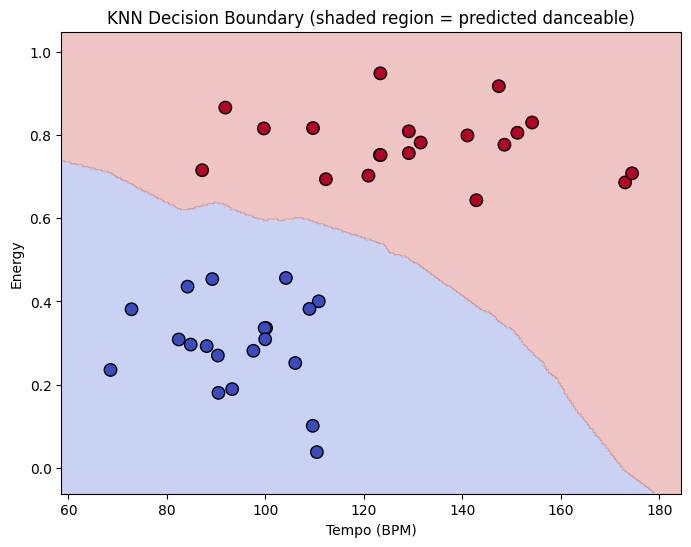

In [9]:
from sklearn.preprocessing import StandardScaler

# Prepare features and labels
### these are the features, throughout the course we will assign them to X
X = songs[['tempo', 'energy']].values

### these are the labels (what we want to predict),
### throughout the course we will assign to y
y = (songs['label'] == 'danceable').astype(int)  # 1 = danceable, 0 = not


# Scale features so KNN distances treat both axes equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y)

# Plot the decision boundary in original feature space
### You do not need to study the visualization code for this class
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10      # tempo axis bounds with padding
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1    # energy axis bounds with padding
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),        # 300-point grid over tempo range
                      np.linspace(y_min, y_max, 300))         # 300-point grid over energy range
Z = knn.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))  # scale grid points before predicting
Z = Z.reshape(xx.shape)                                           # reshape predictions back to 2D grid for plotting

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=80)
plt.xlabel('Tempo (BPM)')
plt.ylabel('Energy')
plt.title('KNN Decision Boundary (shaded region = predicted danceable)')
plt.show()

The red-shaded region shows where the model predicts "danceable." Notice the boundary isn't a straight line. KNN is flexible and adapts to the local structure of the data. Now let's use the model to evaluate a hypothetical new track.

New song: tempo = 130 BPM, energy = 0.75
Prediction: danceable
Confidence: 100.0%


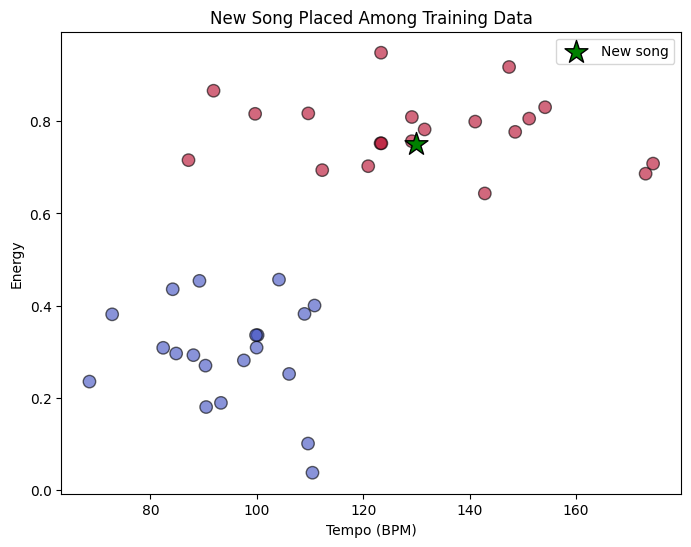

In [10]:
# A new song no model has seen before
new_song = np.array([[130, 0.75]])  # tempo=130 BPM, energy=0.75
prediction = knn.predict(new_song)
probabilities = knn.predict_proba(new_song)

label = 'danceable' if prediction[0] == 1 else 'not danceable'
confidence = probabilities[0].max()

print(f'New song: tempo = 130 BPM, energy = 0.75')
print(f'Prediction: {label}')
print(f'Confidence: {confidence:.1%}')

# Plot where this new song falls relative to the training data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=80, alpha=0.6)
plt.scatter(new_song[0, 0], new_song[0, 1], c='green', marker='*', s=300,
            edgecolors='black', label='New song', zorder=5)
plt.xlabel('Tempo (BPM)')
plt.ylabel('Energy')
plt.title('New Song Placed Among Training Data')
plt.legend()
plt.show()

### Regression: Predicting a Continuous Value

What if instead of a category (danceable or not), we wanted to predict a continuous number? For example, what is the exact number of people who will get up to dance? That's a **regression** problem. Let's quickly demo regression on a different example: predicting house prices from square footage.

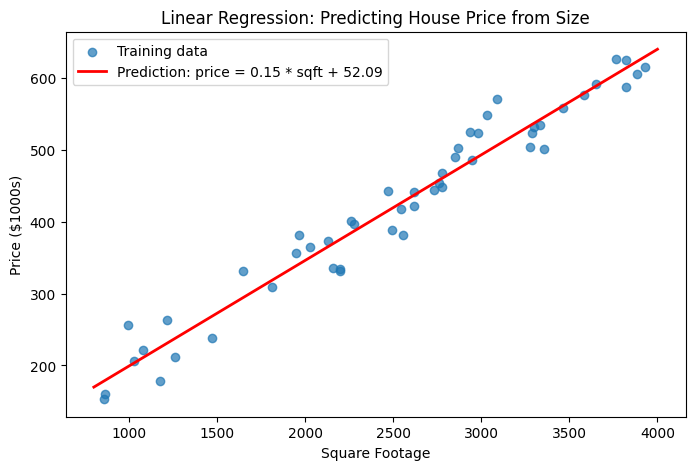

Coefficient (slope): 0.15
Intercept: 52.09
Predicted price for 2000 sqft: $346K


In [11]:
# Generate synthetic house data
np.random.seed(0)
sqft = np.random.uniform(800, 4000, 50)
price = 50 + 0.15 * sqft + np.random.normal(0, 30, 50)  # price in $1000s

# Train a linear regression model
lr = LinearRegression()
lr.fit(sqft.reshape(-1, 1), price)

# Plot the data and the regression line
plt.figure(figsize=(8, 5))
plt.scatter(sqft, price, alpha=0.7, label='Training data')
x_line = np.linspace(800, 4000, 100)
plt.plot(x_line, lr.predict(x_line.reshape(-1, 1)),
         'r-', linewidth=2, label=f'Prediction: price = {lr.coef_[0]:.2f} * sqft + {lr.intercept_:.2f}')
plt.xlabel('Square Footage')
plt.ylabel('Price ($1000s)')
plt.title('Linear Regression: Predicting House Price from Size')
plt.legend()
plt.show()

print(f'Coefficient (slope): {lr.coef_[0]:.2f}')
print(f'Intercept: {lr.intercept_:.2f}')
print(f'Predicted price for 2000 sqft: ${lr.predict([[2000]])[0]:.0f}K')

## Tools Used in This Notebook

All of the code above uses free, open-source Python libraries: **Pandas** for data manipulation, **Matplotlib** for visualization, **NumPy** for numerical computation, and **scikit-learn** for machine learning. We'll use these throughout the semester.

## Your Turn

Try modifying the code above to explore these questions:

1. **Change KNN's `n_neighbors`** from 5 to 1, then to 20. How does the decision boundary change? What happens when `n_neighbors=1`? What about when it's very large?

2. **Add a noisy feature** — Replace `energy` with pure random noise: generate `noise = np.random.uniform(0, 1, len(songs))`. Train KNN on `[tempo, noise]`. How does the decision boundary and prediction confidence compare to using `[tempo, energy]`?

3. **Try a different classifier** — replace `KNeighborsClassifier` with `sklearn.tree.DecisionTreeClassifier`. How does the decision boundary differ?



Now that you know your way around notebooks, let's start working with data.

<a href="16_3_Intro_to_Arrays.ipynb">Continue to: Introduction to NumPy Arrays →</a>